# Signal-only normalization: controlling extreme exposures

This is a focused continuation of `takehome.ipynb`, not a rerun or replacement of its historical results. All data-dependent experiments use the **same training 80%**, all rows, and all 100 predictors. The reserved final 20% is not evaluated.

**Question:** which small changes to signal standardization remove extreme exposure without requiring asset volatility at inference? Compare the original rule, a floor, changing the power from two to one, RMS rather than centered standard deviation, and bounded versions. Parameters are fixed before scoring: half-life/minimum observations 6048, floor 25% of an initial scale, absolute score cap 3. These are not selected by maximizing validation Sharpe.

Let $s_t$ be the already-available forecast, $\sigma_{t-1}$ its lagged EWM standard deviation, $r_{t-1}=\sqrt{\mathrm{EWM}(s^2)_{t-1}}$, and $s_0$ the FIRST valid lagged scale, then frozen. Nothing is estimated from the full test period. Scale updates use zeros/nonfinite-as-missing and `ignore_na=True`, as requested. Missing current signals remain missing; current zero signals give zero exposure once warm.

- **Variance control:** $s_0s_t/\sigma_t^2$, the original rule multiplied by one fixed past-only constant. This changes absolute units but not its subsequent Sharpe or jump concentration. A separate lagged-denominator control isolates the timing change.
- **Floored variance:** $s_0s_t/\max(\sigma_{t-1},0.25s_0)^2$, optionally clipped to $[-3,3]$.
- **Standard deviation:** $s_t/\max(\sigma_{t-1},0.25s_0)$, optionally clipped.
- **RMS:** $s_t/\max(r_{t-1},0.25r_0)$, optionally clipped. A nonzero mean does not create a zero denominator. No signal is demeaned.

The fixed multiplier makes the variance comparison dimensionless; it is not hindsight volatility matching. Cap=3 is an explicit exposure budget, NOT a universal optimal setting. With an overall multiplier of one, $|w_t|\le3$ implies $|w_tR_t|\le3|R_t|$, not a fixed bound on losses. Single-std scaling is closest to ordinary signal standardization; floored/capped variance preserves more of the old weighting shape.

The scale is shifted, not the signal: these inputs are already prior-fold forecasts. The normalizer receives **no returns or prices**. Scoring uses returns only after exposures are constructed. Numerical exposure control does not verify the original `ret_5m` timing, execution assumptions, or transaction costs.

In [1]:
from pathlib import Path
import os, sys, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, JSON
get_ipython().run_line_magic('matplotlib', 'inline')
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'src'/'takehome').exists())
sys.path.insert(0,str(ROOT/'src'))
from takehome.data import training_data
from takehome.features import with_cashflow_feature, ts_std, sharpe
from takehome.fitters import BatchRidge, BatchLasso, walk_forward_sweep
from takehome.normalization import signal_weights
HL=6048
DATA=Path(os.environ.get('DATA_PATH',ROOT/'ESc1_signal_components_5min (6).parquet'))
raw=pd.read_parquet(DATA)
if 'msgStamp' in raw: raw=raw.set_index('msgStamp')
df, split=training_data(raw.sort_index())
del raw
df=with_cashflow_feature(df)
x_cols=list(df.filter(regex=r'^x[0-9]+$').columns)
assert len(x_cols)==100 and x_cols[-1]=='x100'
X=np.ascontiguousarray(df[x_cols].replace([np.inf,-np.inf],np.nan).fillna(0).to_numpy())
y=df.ret_5m.to_numpy(); W=np.isfinite(y).astype(float)
FOLD=dict(min_train_size=252*288,step=HL,train_size=None,gap=0)
print(f'{len(df):,} training rows, {len(x_cols)} predictors; no held-out observations.')
assert len(df)==640734 and df.index.max()<split['cutoff']


640,734 training rows, 100 predictors; no held-out observations.


## Identical forecast inputs for every normalization

Ridge coefficients are fitted on previous folds, then frozen for the next fold. Five predeclared Ridge penalties cover weak through strong shrinkage; batch Lasso at 1e-5 is a second estimator. The model design remains the existing zero-imputed 100-column design, with unit weights on finite labels and no imputed targets. This changes **only position sizing**, not forecasts. The normalized curves are validation diagnostics inside the training period.

A second test freezes two Ridge models for the last two years **inside the training period**. Their forecasts and normalization use only available predictors after the freeze. Scoring returns never enter the normalizer. This simulates the label-blackout constraint without using the reserved test labels.

In [2]:
models={f'Ridge {a:g}':BatchRidge(len(x_cols),alpha=a,decay=2**(-1/HL))
        for a in [1e-6,1e-4,.01,1.,100.]}
models['Lasso 1e-5']=BatchLasso(len(x_cols),decay=2**(-1/HL),alpha=1e-5,fit_intercept=True)
t0=time.perf_counter()
paths=walk_forward_sweep(models,X,y,W=W,**FOLD)
forecast=pd.DataFrame({name:p.prediction_ for name,p in paths.items()},index=df.index)
freeze_date=df.index[-1]-pd.DateOffset(years=2)
freeze_row=int(df.index.searchsorted(freeze_date))
blackout={}
for a in [.01,100.]:
    name=f'Ridge {a:g}'
    fixed=BatchRidge(len(x_cols),alpha=a,decay=2**(-1/HL)).fit(X[:freeze_row],y[:freeze_row],W=W[:freeze_row])
    p=forecast[name].copy()
    p.iloc[freeze_row:]=fixed.predict(X[freeze_row:])
    blackout[name+' blackout']=p
print(f'Forecast generation: {time.perf_counter()-t0:.1f}s; {len(next(iter(paths.values())).folds_)} folds.')
print(f'Simulated price/label blackout starts {df.index[freeze_row]}; coefficients never refit afterward.')


Forecast generation: 40.0s; 94 folds.
Simulated price/label blackout starts 2020-07-14 00:30:00-04:00; coefficients never refit afterward.


## Candidate rules and matched-sample measurement

The same eligible rows are used across rules within each forecast. The old rule uses current-forecast scale; all proposed alternatives use prior-row scale. We measure maximum and 99th-percentile exposure, the proportion capped, largest bar/daily P&L, and the share of total absolute P&L in the largest ten bars. Daily mean/std is secondary. Warm-up and missing target days follow the earlier daily `sum()` convention. No full-sample scale is fitted for charting.

In [3]:
RULES={
    'Original shape':dict(method='variance',floor_fraction=0,cap=None,lag=0),
    'Prior variance':dict(method='variance',floor_fraction=0,cap=None),
    'Floor variance':dict(method='variance',floor_fraction=.25,cap=None),
    'Floor variance + cap':dict(method='variance',floor_fraction=.25,cap=3),
    'Std only':dict(method='std',floor_fraction=0,cap=None),
    'Std + floor + cap':dict(method='std',floor_fraction=.25,cap=3),
    'RMS only':dict(method='rms',floor_fraction=0,cap=None),
    'RMS + floor + cap':dict(method='rms',floor_fraction=.25,cap=3),
}
BOUNDED=['Floor variance + cap','Std + floor + cap','RMS + floor + cap']

def compare(signal, start_row):
    position=pd.DataFrame({k:signal_weights(signal,HL,**v) for k,v in RULES.items()})
    eligible=position.notna().all(axis=1)&df.ret_5m.notna()&(np.arange(len(df))>=start_row)
    w=position.where(eligible)
    pnl=w.mul(df.ret_5m,axis=0)
    daily=pnl.resample('D').sum().loc[df.index[start_row].normalize():]
    records=[]
    for name in position:
        a=w[name].dropna().abs(); p=pnl[name].dropna(); total=p.abs().sum()
        records.append(dict(rule=name,n=len(a),max_abs_weight=a.max(),p99_abs_weight=a.quantile(.99),
            capped_percent=100*a.ge(3-1e-12).mean() if name in BOUNDED else 0.,
            max_abs_bar_pnl=p.abs().max(),max_abs_daily_pnl=daily[name].abs().max(),
            top10_abs_pnl_share=100*p.abs().nlargest(10).sum()/total if total else np.nan,
            daily_sharpe=sharpe(daily[name]),mean_turnover=position[name].diff().abs().where(eligible).mean()))
    return pd.DataFrame(records).set_index('rule'), position, pnl, daily

SCORE_FIRST=FOLD['min_train_size']+HL
records=[]; default=None; sizing_audit={}
for name,p in {**{k:forecast[k] for k in forecast},**blackout}.items():
    start=freeze_row if name.endswith('blackout') else SCORE_FIRST
    stats,pos,pnl,daily=compare(p,start)
    records.append(stats.assign(model=name))
    if name=='Ridge 0.01': default=(stats,pos,pnl,daily)
    if name in ['Ridge 0.01','Ridge 100','Lasso 1e-5','Ridge 0.01 blackout','Ridge 100 blackout']:
        sizing_audit[name]=stats.reset_index().to_dict('records')
    for k in BOUNDED: assert pos[k].abs().max()<=3
all_stats=pd.concat(records).reset_index().set_index(['model','rule'])
p=forecast['Ridge 0.01']; old_sigma=ts_std(p,HL)
old_position=p/old_sigma**2; old_pnl=old_position*df.ret_5m
worst=old_pnl.abs().idxmax()
print('Original raw-unit spike:',worst,'exposure=',float(old_position.loc[worst]),'bar PnL=',float(old_pnl.loc[worst]))
print('Every capped candidate stays within +/-3 across all Ridge/Lasso forecasts and blackout paths.')


Original raw-unit spike: 2015-08-24 09:40:00-04:00 exposure= 405275.2680096536 bar PnL= 8709.743839025477
Every capped candidate stays within +/-3 across all Ridge/Lasso forecasts and blackout paths.


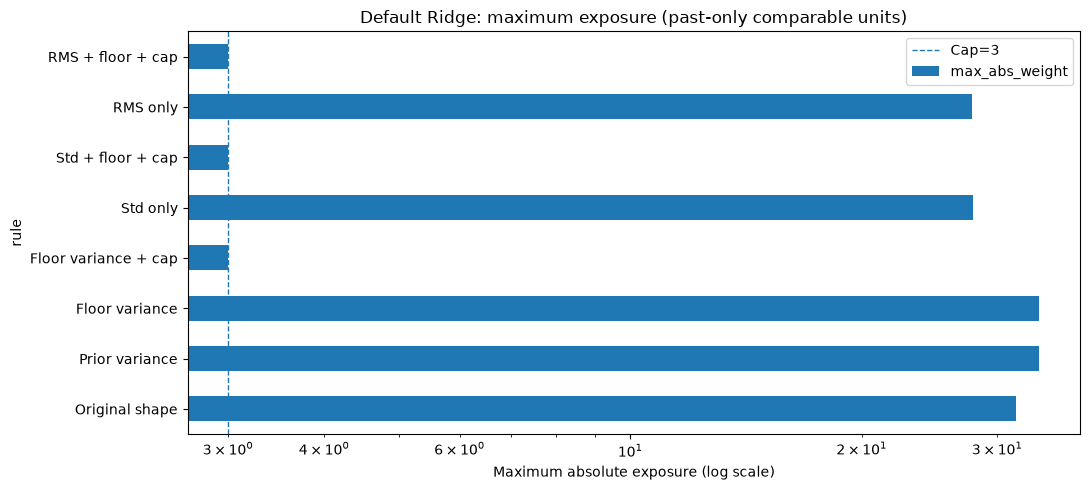

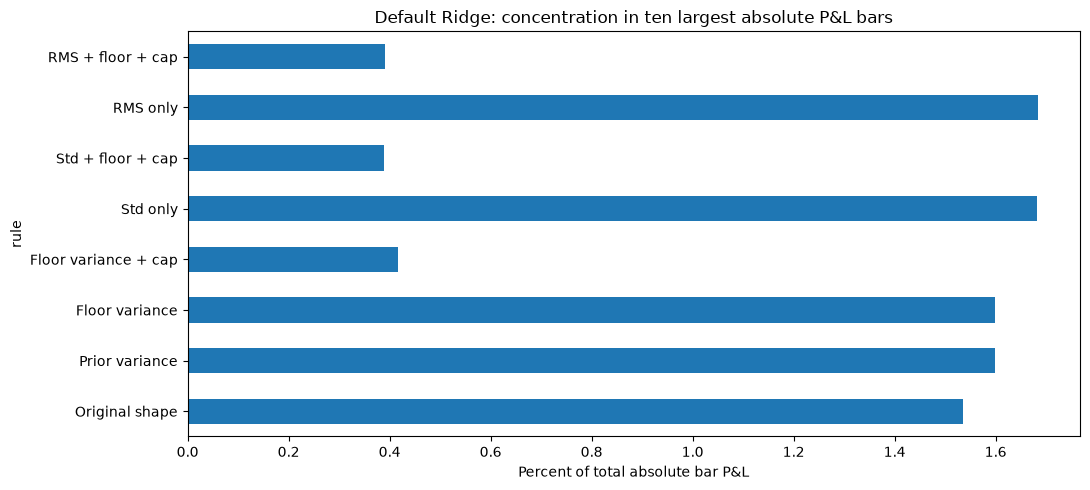

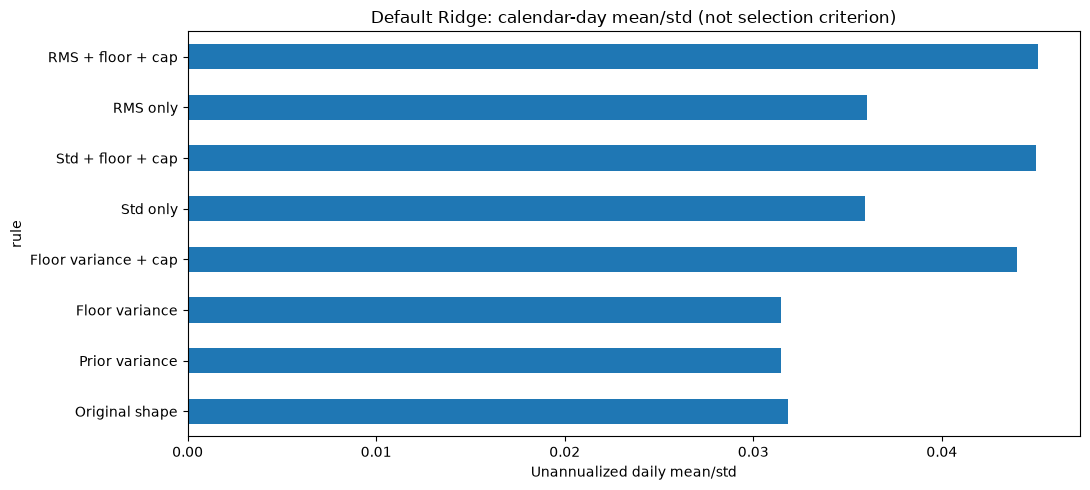

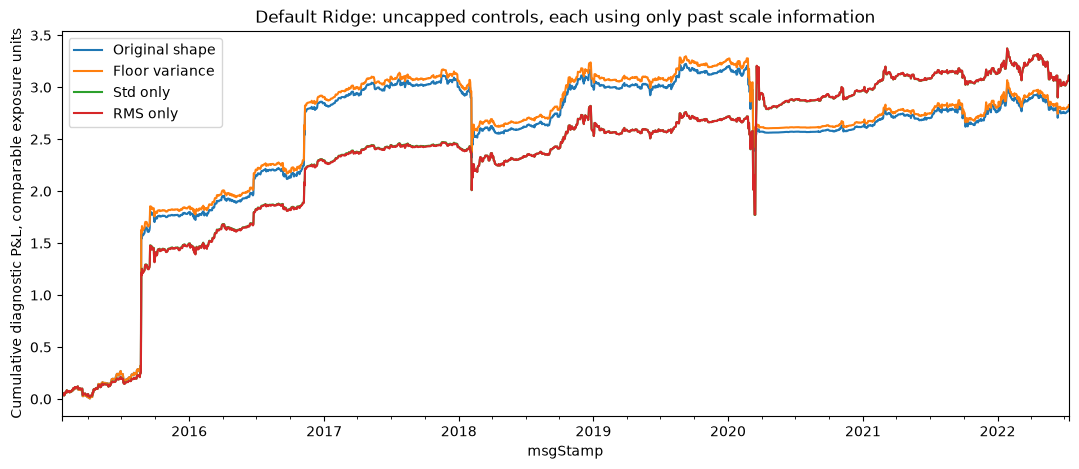

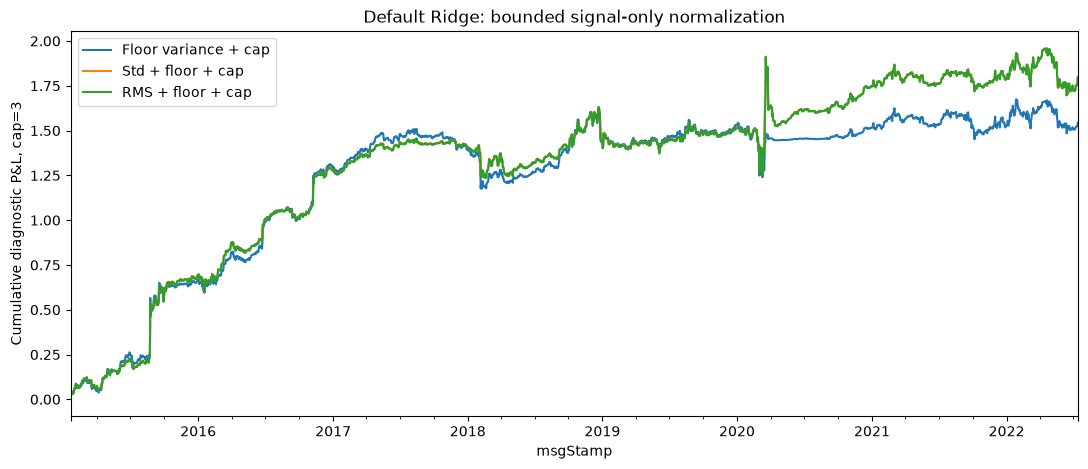

Original shape: peak |w|=31.723; p99=5.02597; largest bar PnL=0.462918; top-ten share=1.536%; daily Sharpe=0.031862
Floor variance + cap: peak |w|=3; p99=3; largest bar PnL=0.0857143; top-ten share=0.417%; daily Sharpe=0.043998
Std + floor + cap: peak |w|=3; p99=3; largest bar PnL=0.0857143; top-ten share=0.389%; daily Sharpe=0.044990
RMS + floor + cap: peak |w|=3; p99=3; largest bar PnL=0.0857143; top-ten share=0.390%; daily Sharpe=0.045075


In [4]:
stats,pos,pnl,daily=default
for field,title,logx in [
    ('max_abs_weight','Default Ridge: maximum exposure (past-only comparable units)',True),
    ('top10_abs_pnl_share','Default Ridge: concentration in ten largest absolute P&L bars',False),
    ('daily_sharpe','Default Ridge: calendar-day mean/std (not selection criterion)',False),
]:
    ax=stats[field].reindex(list(RULES)).plot.barh(figsize=(11,5),logx=logx,title=title)
    ax.set_xlabel({'max_abs_weight':'Maximum absolute exposure (log scale)',
        'top10_abs_pnl_share':'Percent of total absolute bar P&L',
        'daily_sharpe':'Unannualized daily mean/std'}[field])
    if field=='max_abs_weight': ax.axvline(3,linestyle='--',linewidth=1,label='Cap=3'); ax.legend()
    plt.tight_layout(); plt.show(); plt.close('all')
daily[['Original shape','Floor variance','Std only','RMS only']].cumsum().plot(
    figsize=(13,5),title='Default Ridge: uncapped controls, each using only past scale information')
plt.ylabel('Cumulative diagnostic P&L, comparable exposure units'); plt.show(); plt.close('all')
daily[BOUNDED].cumsum().plot(figsize=(13,5),title='Default Ridge: bounded signal-only normalization')
plt.ylabel('Cumulative diagnostic P&L, cap=3'); plt.show(); plt.close('all')
for k in ['Original shape',*BOUNDED]:
    r=stats.loc[k]
    print(f"{k}: peak |w|={r.max_abs_weight:.6g}; p99={r.p99_abs_weight:.6g}; "
          f"largest bar PnL={r.max_abs_bar_pnl:.6g}; top-ten share={r.top10_abs_pnl_share:.3f}%; "
          f"daily Sharpe={r.daily_sharpe:.6f}")


## Robustness across shrinkage and a two-year label blackout

A cap prevents extreme *exposure*, even when the underlying return is unusually large. It cannot turn a weak forecast into alpha or produce constant realized risk without an asset-risk model. Compare within a column/forecast; forecast errors, missingness, and future shocks remain real risks.

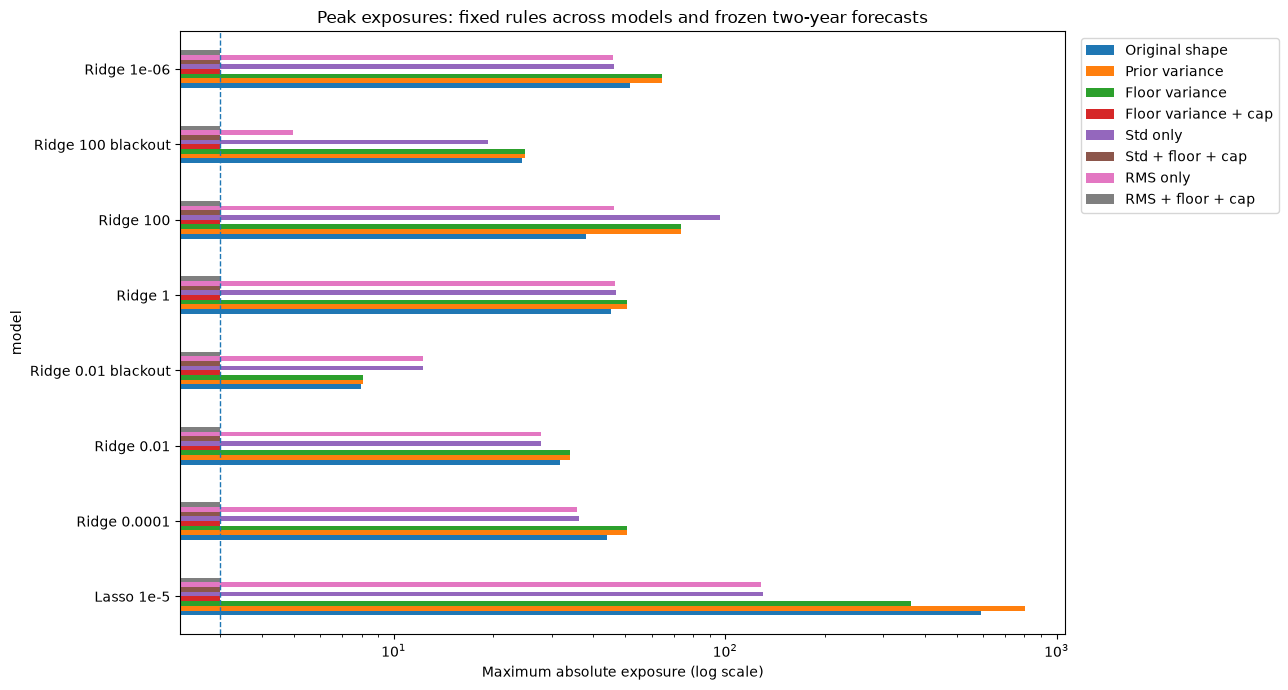

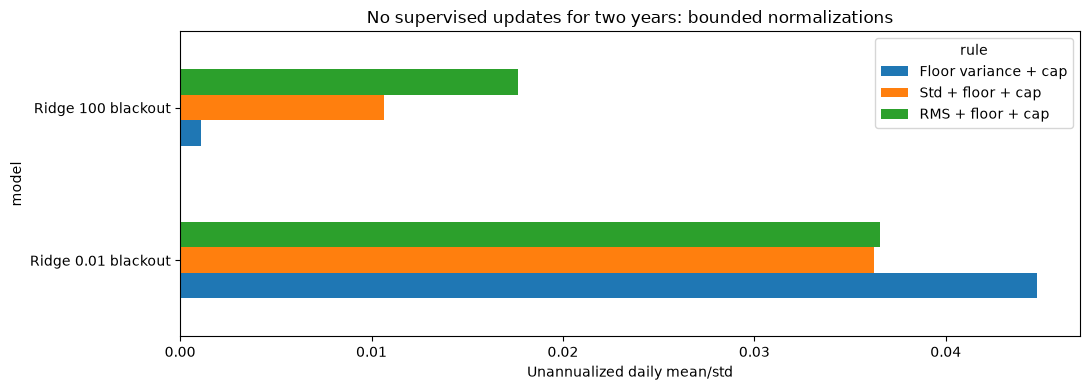

Original shape: worst peak exposure across model paths=590.665
Prior variance: worst peak exposure across model paths=801.541
Floor variance: worst peak exposure across model paths=362.751
Floor variance + cap: worst peak exposure across model paths=3
Std only: worst peak exposure across model paths=130.169
Std + floor + cap: worst peak exposure across model paths=3
RMS only: worst peak exposure across model paths=128.255
RMS + floor + cap: worst peak exposure across model paths=3


In [5]:
peak=all_stats.max_abs_weight.unstack('rule')[list(RULES)]
peak.plot.barh(logx=True,figsize=(13,7),title='Peak exposures: fixed rules across models and frozen two-year forecasts')
plt.axvline(3,linestyle='--',linewidth=1); plt.xlabel('Maximum absolute exposure (log scale)')
plt.legend(loc='upper left',bbox_to_anchor=(1.01,1)); plt.tight_layout(); plt.show(); plt.close('all')
blackout_names=list(blackout)
all_stats.loc[blackout_names].daily_sharpe.unstack('rule')[BOUNDED].plot.barh(
    figsize=(11,4),title='No supervised updates for two years: bounded normalizations')
plt.xlabel('Unannualized daily mean/std'); plt.tight_layout(); plt.show(); plt.close('all')
worst_cases=all_stats.groupby('rule')[['max_abs_weight','max_abs_bar_pnl','top10_abs_pnl_share']].max()
for k in RULES:
    print(f'{k}: worst peak exposure across model paths={worst_cases.loc[k,"max_abs_weight"]:.6g}')


## All 100 raw alphas and adversarial paths

Evaluate every raw alpha on every training row; process one column at a time rather than subsampling observations. This checks that the candidate does not just fix one Ridge path. The synthetic tests deliberately include a nonzero near-constant plateau, a vanishing signal scale, zero/missing stretches, and an unseen spike. A floor can stop denominator collapse; only the cap gives a hard bound against an arbitrarily large new signal.

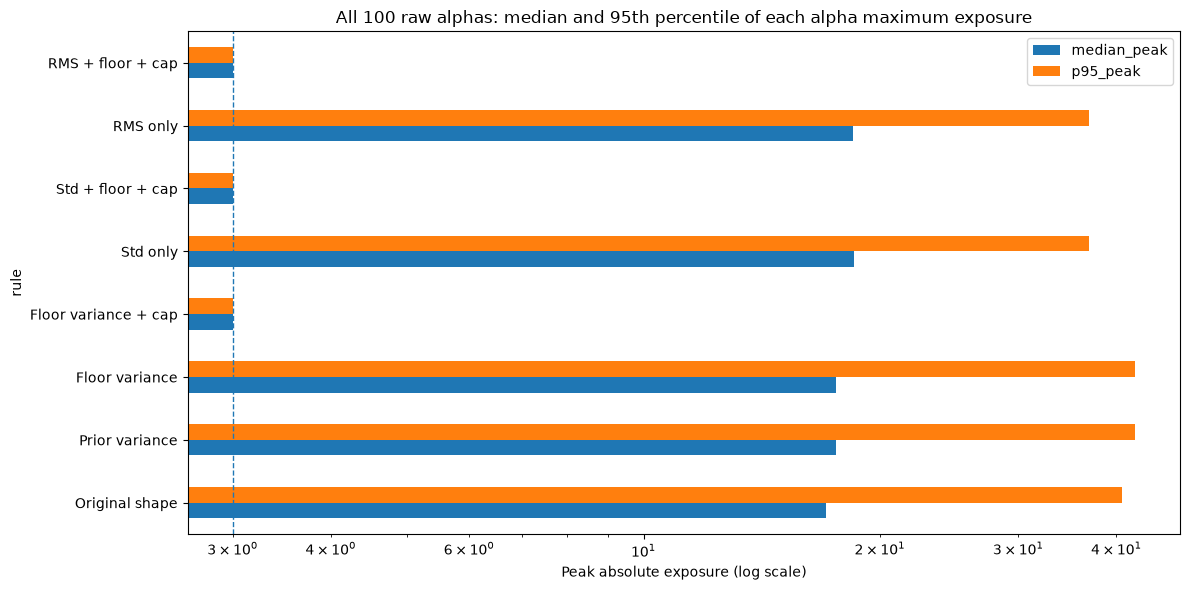

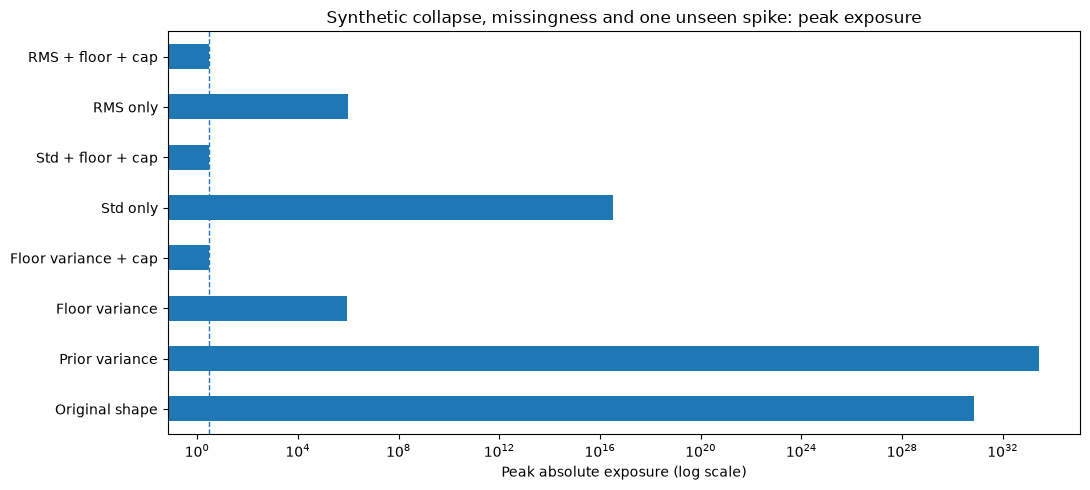

Synthetic exposure peaks: {'Original shape': np.float64(6.901733619722319e+30), 'Prior variance': np.float64(2.639136687222213e+33), 'Floor variance': np.float64(885513.6102553161), 'Floor variance + cap': np.float64(3.0), 'Std only': np.float64(3.2109176915084256e+16), 'Std + floor + cap': np.float64(3.0), 'RMS only': np.float64(959076.6795675792), 'RMS + floor + cap': np.float64(3.0)}
All 100 raw alphas respect the cap, without return-volatility inputs.


In [6]:
raw_records=[]
for col in x_cols:
    for name,kwargs in RULES.items():
        w=signal_weights(df[col],HL,**kwargs)
        a=w.dropna().abs()
        raw_records.append(dict(feature=col,rule=name,n=len(a),peak=a.max(),p99=a.quantile(.99)))
raw_stats=pd.DataFrame(raw_records)
raw_summary=raw_stats.groupby('rule').agg(median_peak=('peak','median'),
    p95_peak=('peak',lambda x:x.quantile(.95)),worst_peak=('peak','max')).reindex(list(RULES))
raw_summary[['median_peak','p95_peak']].plot.barh(logx=True,figsize=(12,6),
    title='All 100 raw alphas: median and 95th percentile of each alpha maximum exposure')
plt.axvline(3,linestyle='--',linewidth=1); plt.xlabel('Peak absolute exposure (log scale)')
plt.tight_layout(); plt.show(); plt.close('all')
assert raw_stats.loc[raw_stats.rule.isin(BOUNDED),'peak'].max()<=3
rng=np.random.default_rng(41)
z=pd.Series(rng.normal(size=3000),index=pd.date_range('2000',periods=3000,freq='5min'))
z.iloc[150:2400]=.001; z.iloc[2400:2500]=0; z.iloc[2600:2700]=np.nan; z.iloc[2900]=1e6
stress={name:signal_weights(z,20,**kwargs).abs().max() for name,kwargs in RULES.items()}
pd.Series(stress).reindex(list(RULES)).plot.barh(logx=True,figsize=(11,5),
    title='Synthetic collapse, missingness and one unseen spike: peak exposure')
plt.axvline(3,linestyle='--',linewidth=1); plt.xlabel('Peak absolute exposure (log scale)')
plt.tight_layout(); plt.show(); plt.close('all')
print('Synthetic exposure peaks:',stress)
print('All 100 raw alphas respect the cap, without return-volatility inputs.')


## Recommended use

**Simplest default:** divide by a lagged, floored standard deviation and clip the result. This keeps the signal direction, removes the extra inverse-volatility factor, and gives an explicit finite exposure bound:

```python
from takehome.normalization import signal_weights
weights = signal_weights(yhat, hl=6048, method='std', floor_fraction=.25, cap=3)
pnl = weights.mul(df['ret_5m'])  # returns are scoring inputs only
pnl.resample('D').sum().cumsum().plot()
```

**Least change to the original inverse-variance weighting:** choose `method='variance'`. The frozen first-scale multiplier makes the score dimensionless; the remaining uncapped shape is the old rule. The cap still guarantees the bound.

**For intercept-dominated, almost constant forecasts:** `method='rms'` includes mean magnitude in the scale instead of dividing by tiny centered variance. It deliberately treats a stable nonzero signal as roughly a unit exposure; that may create directional exposure, so it is not a forecast-validation test.

Do not optimize floor/cap to the best displayed Sharpe. Begin with explicit position-budget choices, then assess stability and costs in chronological validation. No normalizer here promises constant asset risk, profitability, or bounded multi-day drawdown.

For the price-blackout period, replay historical forecasts followed by test forecasts through the same helper; retain EWM history and the frozen reference. Alternatively pass `reference=` learned before the test period, while still warming the EWM history. Do not fit the reference on all test forecasts. The regression generating forecasts must also freeze its supervised state once labels disappear.

The old `features.backtest` default is intentionally unchanged so previous notebooks are reproducible. The safer rule is an explicit replacement for its *position-sizing step*, not a silent rewrite of earlier results.

In [7]:
audit={
    'training_rows':len(df),'reserved_test_used':False,'floor_fraction':.25,'cap':3,'hl':HL,
    'model_results':sizing_audit,
    'raw_alpha_extremes':raw_summary.reset_index().to_dict('records'),
    'stress_peak':stress,
    'old_raw_unit_peak':{'timestamp':str(worst),'weight':float(old_position.loc[worst]),'bar_pnl':float(old_pnl.loc[worst])},
}
# Collapsed numerical audit accompanies the plots; no separate reports are exported.
display(JSON(audit,expanded=False))
assert df.index.max()<split['cutoff']


<IPython.core.display.JSON object>